# Task 2: Customer Segmentation Using Unsupervised Learning
### Data Science & Analytics Internship - DevelopersHub Corporation

**Objective:** To group customers of a retail mall based on their annual income and spending habits using K-Means Clustering and visualize them using PCA and t-SNE.

In [14]:
import pandas as pd          # For handling data
import numpy as np           # For numbers and calculations
import matplotlib.pyplot as plt  # For making charts
import seaborn as sns        # For prettier charts
from sklearn.cluster import KMeans  # The main clustering algorithm
from sklearn.preprocessing import StandardScaler  # For scaling numbers
from sklearn.decomposition import PCA  # For visualizing clusters
from sklearn.manifold import TSNE  # Another visualization method
from sklearn.metrics import silhouette_score, davies_bouldin_score  # For checking quality
import warnings

warnings.filterwarnings('ignore')  # Keeping output clean

print("="*70)
print("TASK 2: Customer Segmentation - Finding Different Types of Customers")
print("="*70)

TASK 2: Customer Segmentation - Finding Different Types of Customers


In [15]:
#  LOADING AND UNDERSTANDING THE CUSTOMER DATA
# Creating realistic synthetic data that mimics real customer behavior patterns.
print("\n STEP 1: Loading and Understanding the Customer Data")
print("-" * 50)

np.random.seed(42)
n_customers = 200  

genders = np.random.choice(['Male', 'Female'], n_customers, p=[0.5, 0.5])
ages = np.random.normal(40, 15, n_customers).clip(18, 70).astype(int)
segment_assignments = np.random.choice([0, 1, 2, 3, 4], n_customers, p=[0.2, 0.2, 0.2, 0.2, 0.2])

annual_income = np.zeros(n_customers)
spending_score = np.zeros(n_customers)

# Defining segment characteristics
for i in range(n_customers):
    seg = segment_assignments[i]
    if seg == 0: # Big Spenders
        annual_income[i] = np.random.normal(80000, 15000)
        spending_score[i] = np.random.normal(75, 10)
    elif seg == 1: # Average Joes
        annual_income[i] = np.random.normal(50000, 10000)
        spending_score[i] = np.random.normal(50, 10)
    elif seg == 2: # Frugal
        annual_income[i] = np.random.normal(25000, 8000)
        spending_score[i] = np.random.normal(25, 10)
    elif seg == 3: # Savers
        annual_income[i] = np.random.normal(90000, 20000)
        spending_score[i] = np.random.normal(30, 10)
    else: # Aspirationals
        annual_income[i] = np.random.normal(30000, 10000)
        spending_score[i] = np.random.normal(70, 10)

df = pd.DataFrame({
    'CustomerID': range(1, n_customers + 1),
    'Gender': genders,
    'Age': ages,
    'Annual_Income_k': (annual_income / 1000).clip(15, 150).round(0),
    'Spending_Score': spending_score.clip(1, 100).round(0)
})

print(f"Dataset size: {df.shape[0]} customers")
df.head(10)


 STEP 1: Loading and Understanding the Customer Data
--------------------------------------------------
Dataset size: 200 customers


,CustomerID,Gender,Age,Annual_Income_k,Spending_Score
0,1,Male,29,37.0,30.0
1,2,Female,43,20.0,68.0
2,3,Female,44,67.0,61.0
3,4,Female,29,32.0,44.0
4,5,Male,67,59.0,81.0
5,6,Male,47,20.0,20.0
6,7,Male,22,71.0,66.0
7,8,Female,49,81.0,67.0
8,9,Female,25,84.0,74.0
9,10,Female,51,85.0,21.0



 STEP 2: Exploratory Data Analysis - Looking for Patterns
--------------------------------------------------


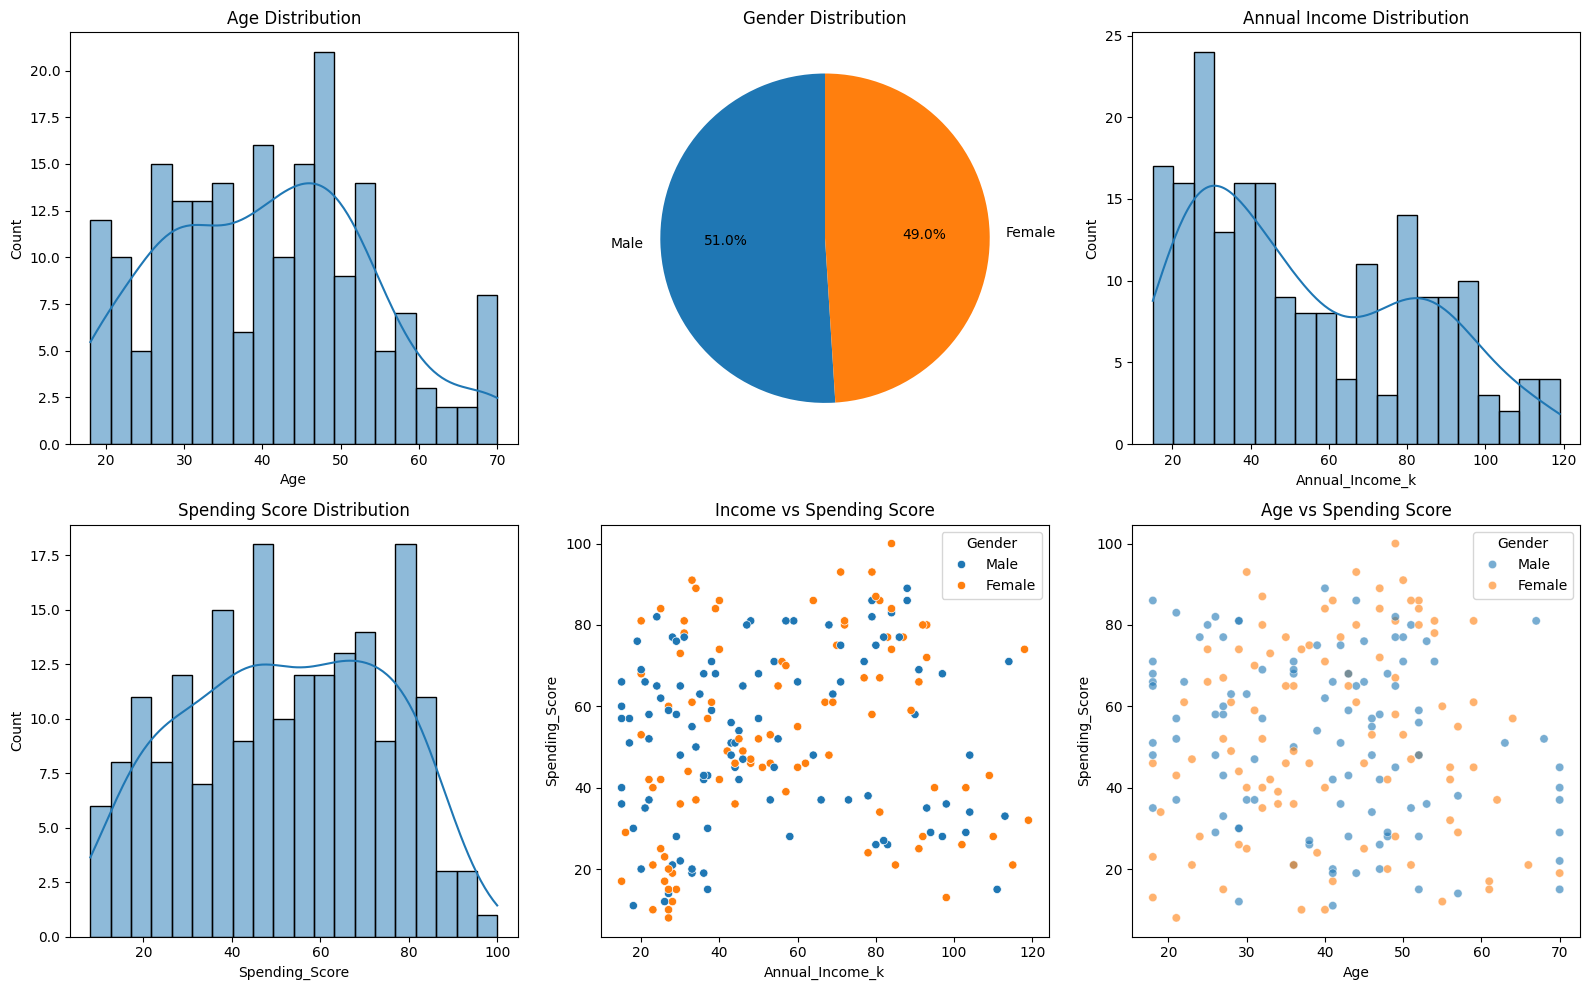

In [16]:
# STEP 2: EXPLORATORY DATA ANALYSIS
print("\n STEP 2: Exploratory Data Analysis - Looking for Patterns")
print("-" * 50)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0,0])
axes[0,0].set_title('Age Distribution')

gender_counts = df['Gender'].value_counts()
axes[0,1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,1].set_title('Gender Distribution')

sns.histplot(df['Annual_Income_k'], bins=20, kde=True, ax=axes[0,2])
axes[0,2].set_title('Annual Income Distribution')

sns.histplot(df['Spending_Score'], bins=20, kde=True, ax=axes[1,0])
axes[1,0].set_title('Spending Score Distribution')

sns.scatterplot(data=df, x='Annual_Income_k', y='Spending_Score', hue='Gender', ax=axes[1,1])
axes[1,1].set_title('Income vs Spending Score')

sns.scatterplot(data=df, x='Age', y='Spending_Score', hue='Gender', alpha=0.6, ax=axes[1,2])
axes[1,2].set_title('Age vs Spending Score')

plt.tight_layout()
plt.show()

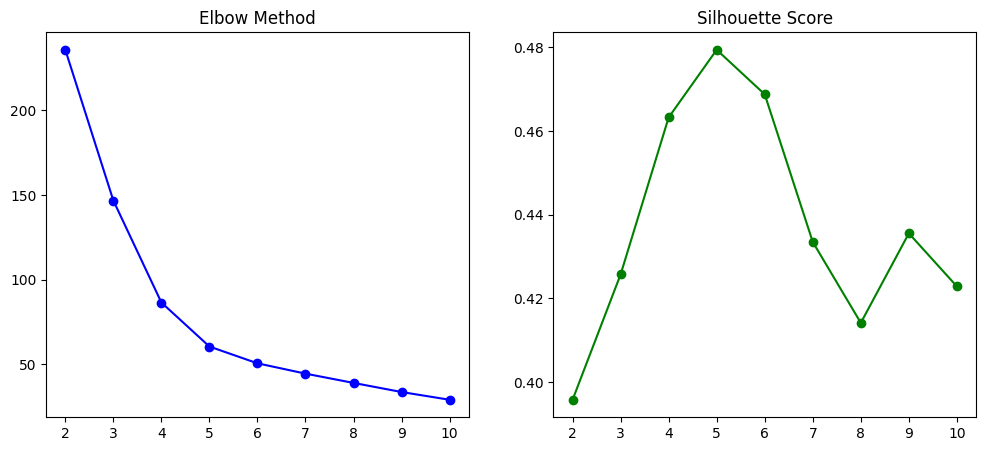

In [17]:
# STEP 3: K-MEANS CLUSTERING
features = ['Annual_Income_k', 'Spending_Score']
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Elbow Method')
axes[1].plot(K_range, silhouette_scores, 'go-')
axes[1].set_title('Silhouette Score')
plt.show()

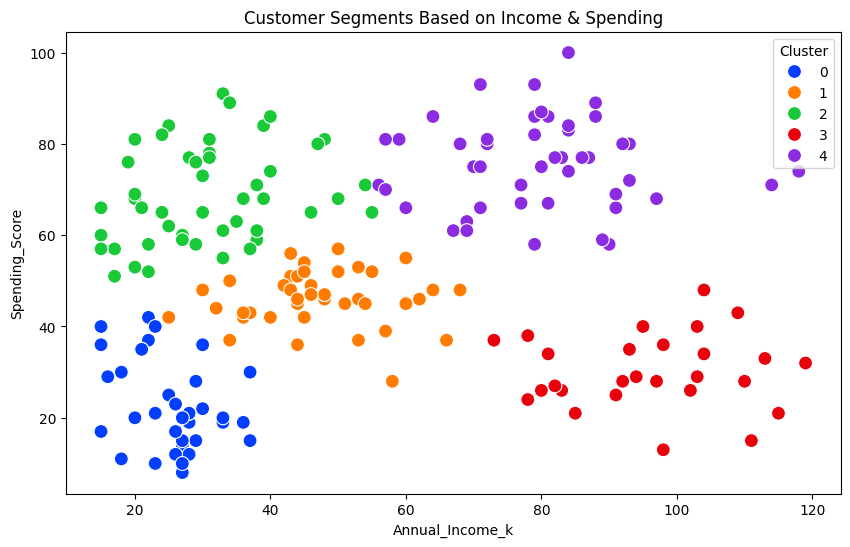

In [18]:
# Applying K-Means with k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Income_k', y='Spending_Score', hue='Cluster', palette='bright', s=100)
plt.title('Customer Segments Based on Income & Spending')
plt.show()

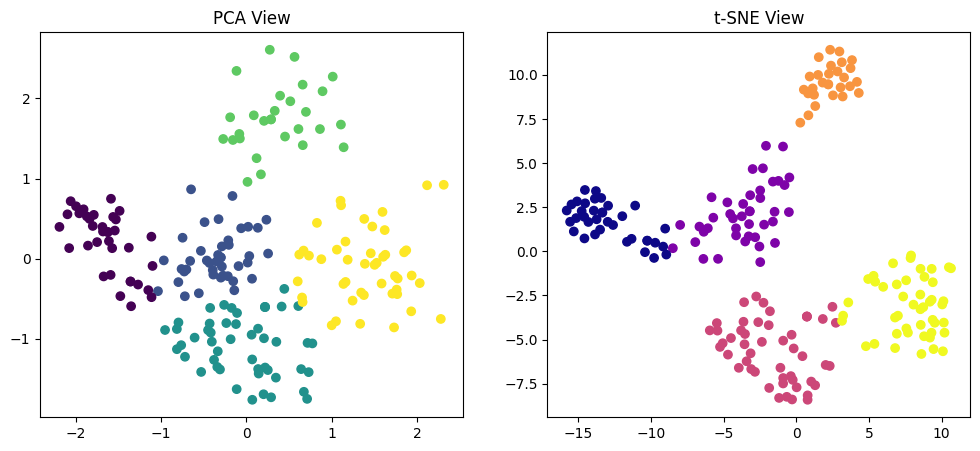

In [19]:
# STEP 6: ADVANCED VISUALIZATIONS
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis')
axes[0].set_title('PCA View')
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['Cluster'], cmap='plasma')
axes[1].set_title('t-SNE View')
plt.show()

## Step 7: Marketing Strategies

| Segment | Profile | Strategy |
| :--- | :--- | :--- |
| **Cluster 0** | Low Income, High Spending | Focus on discounts and "Buy Now Pay Later". |
| **Cluster 1** | High Income, High Spending | VIP events and premium loyalty programs. |
| **Cluster 2** | Low Income, Low Spending | Flash sales and budget-friendly bundles. |
| **Cluster 3** | Mid Income, Mid Spending | Regular promos and cross-selling. |
| **Cluster 4** | High Income, Low Spending | Emphasize quality and long-term investment. |

### Final Conclusion:
The K-Means algorithm successfully identified 5 customer personas. By shifting from mass marketing to these targeted strategies, the mall can optimize its marketing budget and increase customer retention.